In [39]:
import torch; 
from torch import nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torchvision
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)

In [34]:
transform = transforms.Compose([transforms.Resize((64,64)),
                                transforms.ToTensor(),
                                transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
                                ])

dataset_train = datasets.ImageFolder(root='../data/dataset2-master/dataset2-master/images/TRAIN', 
                               transform=transform)
dataset_test = datasets.ImageFolder(root='../data/dataset2-master/dataset2-master/images/TEST', 
                               transform=transform)

train_loader = DataLoader(dataset_train, batch_size=32, shuffle=True)
test_loader = DataLoader(dataset_test, batch_size=32, shuffle=False)

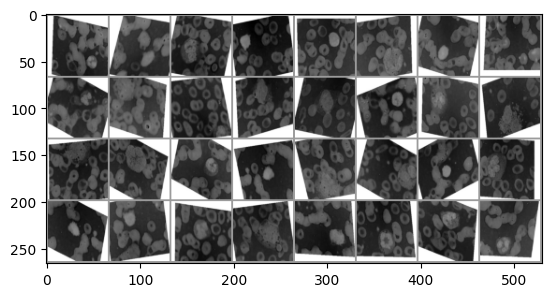

In [ ]:
# Helper function for inline image display
def matplotlib_imshow(img, one_channel=False):
    if one_channel:
        img = img.mean(dim=0)
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    if one_channel:
        plt.imshow(npimg, cmap="Greys")
    else:
        plt.imshow(np.transpose(npimg, (1, 2, 0)))

dataiter = iter(train_loader)
images, labels = next(dataiter)

# Create a grid from the images and show them
img_grid = torchvision.utils.make_grid(images)
matplotlib_imshow(img_grid, one_channel=True)

## LeNet-5 Adaptado

- Ajustar el tamaño de entrada a 64×64×3
- Mantener la estructura original: 2 bloques conv-pool + 3 capas FC
- Añadir una variante con Batch Normalization después de cada capa convolucional

### Arquitectura
| Capa | Tipo | Filtros | Kernel | Salida |
|------|------|---------|--------|--------|
| Input | - | - | - | (3, 64, 64) |
| C1 | Conv2D | 6 | 5x5 | (6, 60, 60) |
| S2 | MaxPool | - | 2x2 | (6, 30, 30) |
| C3 | Conv2D | 16 | 5x5 | (16, 26, 26) |
| S4 | MaxPool | - | 2x2 | (16, 13, 13) |
| Flatten | - | - | - | 2704 |
| FC1 | Linear | - | - | 120 |
| FC2 | Linear | - | - | 84 |
| Output | Linear | - | - | 4 |

In [5]:
class LeNet5(nn.Module):
    def __init__(self):
        super().__init__()
        # Capas
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=6, kernel_size=5)
        self.pool = nn.MaxPool2d(kernel_size=2)
        self.conv2 = nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5)
        self.fc1 = nn.Linear(in_features=2704, out_features=120)
        self.fc2 = nn.Linear(in_features=120, out_features=84)
        self.out = nn.Linear(in_features=84, out_features=4)
        
    def forward(self, x):
        # Flujo
        x = F.relu(self.conv1(x))
        x = self.pool(x)
        x = F.relu(self.conv2(x))
        x = self.pool(x)
        x = x.reshape(x.shape[0], -1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.out(x)
        return x

In [6]:
model = LeNet5()
x = torch.randn(1, 3, 64, 64)
print(model(x).shape)

torch.Size([1, 4])


In [22]:
total_param = 0
for t in model.parameters():
    total_param += t.numel()

print(total_param)

337976


### Con Batch Normalization

In [7]:
class LeNet5BN(nn.Module):
    def __init__(self):
        super().__init__()
        # Capas
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=6, kernel_size=5)
        self.bn1 = nn.BatchNorm2d(6)
        self.pool = nn.MaxPool2d(kernel_size=2)
        self.conv2 = nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5)
        self.bn2 = nn.BatchNorm2d(16)
        self.fc1 = nn.Linear(in_features=2704, out_features=120)
        self.fc2 = nn.Linear(in_features=120, out_features=84)
        self.out = nn.Linear(in_features=84, out_features=4)
        
    def forward(self, x):
        # Flujo
        x = F.relu(self.conv1(x))
        x = self.bn1(x)
        x = self.pool(x)
        x = F.relu(self.conv2(x))
        x = self.bn2(x)
        x = self.pool(x)
        x = x.reshape(x.shape[0], -1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.out(x)
        return x

In [8]:
model_bn = LeNet5BN()
x = torch.randn(1, 3, 64, 64)
print(model_bn(x).shape)

torch.Size([1, 4])


In [21]:
total_param = 0
for t in model_bn.parameters():
    total_param += t.numel()

print(total_param)

338020


## VGG-11 Simplificado
### Arquitectura 
| Capa | Tipo | Filtros | Kernel | Salida |
|------|------|---------|--------|--------|
| Input | - | - | - | (3, 64, 64) |
| Conv1 | Conv2D | 32 | 3x3 | (32, 64, 64) |
| Pool1 | MaxPool | - | 2x2 | (32, 32, 32) |
| Conv2 | Conv2D | 64 | 3x3 | (64, 32, 32) |
| Pool2 | MaxPool | - | 2x2 | (64, 16, 16) |
| Conv3 | Conv2D | 128 | 3x3 | (128, 16, 16) |
| Conv4 | Conv2D | 128 | 3x3 | (128, 16, 16) |
| Pool3 | MaxPool | - | 2x2 | (128, 8, 8) |
| Conv5 | Conv2D | 256 | 3x3 | (256, 8, 8) |
| Conv6 | Conv2D | 256 | 3x3 | (256, 8, 8) |
| Pool4 | MaxPool | - | 2x2 | (256, 4, 4) |
| Conv7 | Conv2D | 256 | 3x3 | (256, 4, 4) |
| Conv8 | Conv2D | 256 | 3x3 | (256, 4, 4) |
| Pool5 | MaxPool | - | 2x2 | (256, 2, 2) |
| Flatten | - | - | - | 1024 |
| FC1 | Linear | - | - | 2048 |
| FC2 | Linear | - | - | 2048 |
| Output | Linear | - | - | 4 |

In [11]:
class VGG11(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.conv4 = nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, padding=1)
        self.conv5 = nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding=1)
        self.conv6 = nn.Conv2d(in_channels=256, out_channels=256, kernel_size=3, padding=1)
        self.conv7 = nn.Conv2d(in_channels=256, out_channels=256, kernel_size=3, padding=1)
        self.conv8 = nn.Conv2d(in_channels=256, out_channels=256, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(in_features=1024, out_features=2048)
        self.fc2 = nn.Linear(in_features=2048, out_features=2048)
        self.out = nn.Linear(in_features=2048, out_features=4)


    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool(x)
        x = F.relu(self.conv2(x))
        x = self.pool(x)
        x = F.relu(self.conv3(x))
        x = F.relu(self.conv4(x))
        x = self.pool(x)
        x = F.relu(self.conv5(x))
        x = F.relu(self.conv6(x))
        x = self.pool(x)
        x = F.relu(self.conv7(x))
        x = F.relu(self.conv8(x))
        x = self.pool(x)
        x = x.reshape(x.shape[0], -1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.out(x)
        
        return x



In [12]:
model_vgg = VGG11()
x = torch.randn(1, 3, 64, 64)
print(model_vgg(x).shape)

torch.Size([1, 4])


In [20]:
total_param = 0
for t in model_vgg.parameters():
    total_param += t.numel()

print(total_param)

8609988


### Con Batch Normalization

In [13]:
class VGG11BN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.pool = nn.MaxPool2d(2)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.conv4 = nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, padding=1)
        self.conv5 = nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(128)
        self.bn5 = nn.BatchNorm2d(256)
        self.conv6 = nn.Conv2d(in_channels=256, out_channels=256, kernel_size=3, padding=1)
        self.conv7 = nn.Conv2d(in_channels=256, out_channels=256, kernel_size=3, padding=1)
        self.conv8 = nn.Conv2d(in_channels=256, out_channels=256, kernel_size=3, padding=1)
        self.bn6 = nn.BatchNorm2d(256)
        self.bn7 = nn.BatchNorm2d(256)
        self.bn8 = nn.BatchNorm2d(256)
        self.fc1 = nn.Linear(in_features=1024, out_features=2048)
        self.fc2 = nn.Linear(in_features=2048, out_features=2048)
        self.out = nn.Linear(in_features=2048, out_features=4)


    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.bn1(x)
        x = self.pool(x)
        x = F.relu(self.conv2(x))
        x = self.bn2(x)
        x = self.pool(x)
        x = F.relu(self.conv3(x))
        x = self.bn3(x)
        x = F.relu(self.conv4(x))
        x = self.bn4(x)
        x = self.pool(x)
        x = F.relu(self.conv5(x))
        x = self.bn5(x)
        x = F.relu(self.conv6(x))
        x = self.bn6(x)
        x = self.pool(x)
        x = F.relu(self.conv7(x))
        x = self.bn7(x)
        x = F.relu(self.conv8(x))
        x = self.bn8(x)
        x = self.pool(x)
        x = x.reshape(x.shape[0], -1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.out(x)
        
        return x



In [ ]:
model_vgg_bn = VGG11BN()
X = torch.randn(1 , 3, 64 , 64)
print(model_vgg_bn(x).shape)

torch.Size([1, 4])


In [19]:
total_param = 0
for t in model_vgg_bn.parameters():
    total_param += t.numel()

print(total_param)

8612740


In [56]:
import time

def train(model, train_loader,  test_loader, epochs, device ,lr):
    metrics_e = {}
    loss_fn = nn.CrossEntropyLoss()
    optimizer =torch.optim.Adam(model.parameters(), lr=lr)
    
    for epoch in range(epochs):
        start = time.time()
        total_loss = 0
        for i, data in enumerate(train_loader):
            inputs, labels =  data
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()

            outputs =  model(inputs)

            loss = loss_fn(outputs, labels)
            loss.backward()
            
            optimizer.step()

            total_loss += loss.item()


        running_tloss = 0
        correct = 0
        total = 0
        model.eval()
        with torch.no_grad():
            for i, tdata in enumerate(test_loader):
                tinputs, tlabels = tdata
                tinputs, tlabels = tinputs.to(device), tlabels.to(device)
                toutputs = model(tinputs)
                tloss = loss_fn(toutputs, tlabels)
                running_tloss += tloss

                predictions = torch.argmax(toutputs, dim=1)
                correct += (predictions == tlabels).sum().item()
                total += tlabels.size(0)
        model.train()
        accuracy = correct / total
        avg_loss = total_loss / len(train_loader)
        test_loss = running_tloss/len(test_loader)
        epoch_time = time.time() - start

        metrics_e[epoch] = {
            "train_loss" :avg_loss,
            "test_loss": test_loss,
            "test_accuracy": accuracy,
            "epoch_time": epoch_time
        }
        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {avg_loss:.4f} | Test Loss: {test_loss:.4f} | Accuracy: {accuracy:.4f} | Time: {epoch_time:.2f}s")
    return metrics_e

            
    

In [50]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [61]:
# LeNet5
model_lenet = LeNet5().to(device)
metrics_lenet = train(model_lenet, train_loader, test_loader, epochs=40, device=device, lr=0.0001)

Epoch 1/40 | Train Loss: 1.3850 | Test Loss: 1.3745 | Accuracy: 0.3148 | Time: 11.10s
Epoch 2/40 | Train Loss: 1.3321 | Test Loss: 1.2725 | Accuracy: 0.4246 | Time: 9.68s
Epoch 3/40 | Train Loss: 1.2116 | Test Loss: 1.2250 | Accuracy: 0.3583 | Time: 11.35s
Epoch 4/40 | Train Loss: 1.1489 | Test Loss: 1.2346 | Accuracy: 0.3060 | Time: 11.88s
Epoch 5/40 | Train Loss: 1.0949 | Test Loss: 1.1601 | Accuracy: 0.4403 | Time: 11.92s
Epoch 6/40 | Train Loss: 1.0609 | Test Loss: 1.1882 | Accuracy: 0.3836 | Time: 11.73s
Epoch 7/40 | Train Loss: 1.0105 | Test Loss: 1.1322 | Accuracy: 0.4761 | Time: 12.16s
Epoch 8/40 | Train Loss: 0.9662 | Test Loss: 1.0637 | Accuracy: 0.4978 | Time: 12.18s
Epoch 9/40 | Train Loss: 0.9190 | Test Loss: 1.0051 | Accuracy: 0.5553 | Time: 12.09s
Epoch 10/40 | Train Loss: 0.8677 | Test Loss: 1.0165 | Accuracy: 0.5336 | Time: 11.99s
Epoch 11/40 | Train Loss: 0.8253 | Test Loss: 0.9247 | Accuracy: 0.5871 | Time: 11.82s
Epoch 12/40 | Train Loss: 0.7820 | Test Loss: 0.9359 

In [62]:
torch.save(model_lenet.state_dict(), '../results/lenet_weights.pth')

In [63]:
# LeNet5 BN
model_lenet_bn = LeNet5BN().to(device)
metrics_lenet_bn = train(model_lenet_bn, train_loader, test_loader, epochs=40, device=device, lr=0.0001)

Epoch 1/40 | Train Loss: 1.3017 | Test Loss: 1.3285 | Accuracy: 0.3587 | Time: 11.67s
Epoch 2/40 | Train Loss: 1.1009 | Test Loss: 1.2713 | Accuracy: 0.4061 | Time: 12.39s
Epoch 3/40 | Train Loss: 0.8748 | Test Loss: 1.2767 | Accuracy: 0.4198 | Time: 12.51s
Epoch 4/40 | Train Loss: 0.6637 | Test Loss: 1.2626 | Accuracy: 0.4343 | Time: 12.51s
Epoch 5/40 | Train Loss: 0.4963 | Test Loss: 1.2465 | Accuracy: 0.4853 | Time: 10.56s
Epoch 6/40 | Train Loss: 0.3818 | Test Loss: 1.3836 | Accuracy: 0.4745 | Time: 11.93s
Epoch 7/40 | Train Loss: 0.2909 | Test Loss: 1.2731 | Accuracy: 0.5211 | Time: 12.86s
Epoch 8/40 | Train Loss: 0.2183 | Test Loss: 1.2933 | Accuracy: 0.5364 | Time: 12.32s
Epoch 9/40 | Train Loss: 0.1600 | Test Loss: 1.3881 | Accuracy: 0.5235 | Time: 12.93s
Epoch 10/40 | Train Loss: 0.1207 | Test Loss: 1.4338 | Accuracy: 0.5424 | Time: 12.36s
Epoch 11/40 | Train Loss: 0.0874 | Test Loss: 1.5882 | Accuracy: 0.5219 | Time: 12.66s
Epoch 12/40 | Train Loss: 0.0575 | Test Loss: 1.6642

In [64]:
torch.save(model_lenet_bn.state_dict(), '../results/lenetbn_weights.pth')

In [65]:
# VGG11
model_vgg = VGG11().to(device)
metrics_vgg = train(model_vgg, train_loader, test_loader, epochs=40, device=device, lr=0.0001)

Epoch 1/40 | Train Loss: 1.3767 | Test Loss: 1.3008 | Accuracy: 0.3844 | Time: 12.17s
Epoch 2/40 | Train Loss: 1.0353 | Test Loss: 0.9054 | Accuracy: 0.6031 | Time: 16.65s
Epoch 3/40 | Train Loss: 0.6167 | Test Loss: 0.5895 | Accuracy: 0.7205 | Time: 12.56s
Epoch 4/40 | Train Loss: 0.4647 | Test Loss: 0.5626 | Accuracy: 0.7857 | Time: 12.81s
Epoch 5/40 | Train Loss: 0.3730 | Test Loss: 0.5222 | Accuracy: 0.8255 | Time: 12.99s
Epoch 6/40 | Train Loss: 0.2892 | Test Loss: 0.8861 | Accuracy: 0.7680 | Time: 12.93s
Epoch 7/40 | Train Loss: 0.2354 | Test Loss: 0.5492 | Accuracy: 0.8368 | Time: 12.85s
Epoch 8/40 | Train Loss: 0.2262 | Test Loss: 0.6549 | Accuracy: 0.8199 | Time: 12.99s
Epoch 9/40 | Train Loss: 0.1708 | Test Loss: 0.4870 | Accuracy: 0.8042 | Time: 13.21s
Epoch 10/40 | Train Loss: 0.1471 | Test Loss: 0.7193 | Accuracy: 0.8247 | Time: 13.23s
Epoch 11/40 | Train Loss: 0.1127 | Test Loss: 0.8384 | Accuracy: 0.8271 | Time: 12.85s
Epoch 12/40 | Train Loss: 0.0965 | Test Loss: 1.3248

In [66]:
torch.save(model_vgg.state_dict(), '../results/vgg11_weights.pth')

In [67]:
# VGG11 BN
model_vgg_bn = VGG11BN().to(device)
metrics_vgg_bn = train(model_vgg_bn, train_loader, test_loader, epochs=40, device=device, lr=0.0001)


Epoch 1/40 | Train Loss: 0.6637 | Test Loss: 0.4815 | Accuracy: 0.7780 | Time: 13.07s
Epoch 2/40 | Train Loss: 0.1914 | Test Loss: 0.8979 | Accuracy: 0.7543 | Time: 13.21s
Epoch 3/40 | Train Loss: 0.1055 | Test Loss: 0.9777 | Accuracy: 0.7857 | Time: 13.25s
Epoch 4/40 | Train Loss: 0.0811 | Test Loss: 1.7451 | Accuracy: 0.6498 | Time: 13.41s
Epoch 5/40 | Train Loss: 0.0758 | Test Loss: 1.1383 | Accuracy: 0.7768 | Time: 13.19s
Epoch 6/40 | Train Loss: 0.0304 | Test Loss: 1.7303 | Accuracy: 0.7326 | Time: 13.41s
Epoch 7/40 | Train Loss: 0.0527 | Test Loss: 1.4154 | Accuracy: 0.7105 | Time: 13.38s
Epoch 8/40 | Train Loss: 0.0516 | Test Loss: 1.2970 | Accuracy: 0.7326 | Time: 13.12s
Epoch 9/40 | Train Loss: 0.0412 | Test Loss: 0.9643 | Accuracy: 0.7821 | Time: 13.06s
Epoch 10/40 | Train Loss: 0.0141 | Test Loss: 0.9629 | Accuracy: 0.7764 | Time: 12.94s
Epoch 11/40 | Train Loss: 0.0408 | Test Loss: 0.9936 | Accuracy: 0.7929 | Time: 12.92s
Epoch 12/40 | Train Loss: 0.0138 | Test Loss: 1.5946

In [68]:
torch.save(model_vgg_bn.state_dict(), '../results/vgg11bn_weights.pth')

## Comparacion de parametros entre arquitecturas CNN

Se comparo la cantidad de parametros entrenables entre las arquitecturas LeNet5 y VGG11, incluyendo sus variantes con Batch Normalization (BN).

| Arquitectura | Parametros |
|---|---:|
| LENET5 | 337976 |
| LENET5 BN | 338020 |
| VGG11 | 8609988 |
| VGG11 BN | 8612740 |

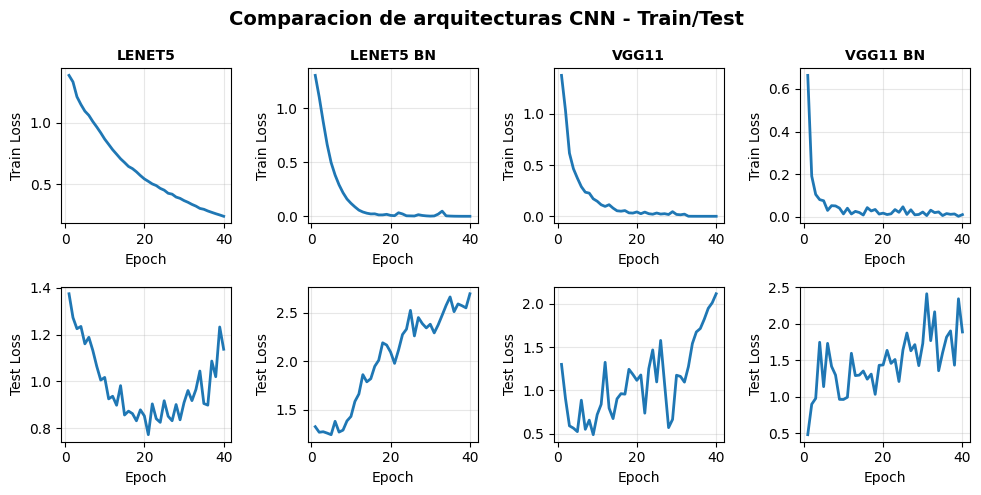

In [106]:
fig, axes = plt.subplots(2,4,figsize=(10,5))

metrics = [metrics_lenet, metrics_lenet_bn, metrics_vgg, metrics_vgg_bn]
titles = ['LENET5', 'LENET5 BN', 'VGG11', 'VGG11 BN']

for i, metric in enumerate(metrics):

    train_losses = [metric[i]['train_loss'] for i in metric]
    axes[0][i].plot(
        range(1,len(train_losses)+1),
        train_losses,
        linewidth=2
    )

    axes[0][i].set_title(titles[i], fontsize=10, fontweight='bold')
    axes[0][i].set_xlabel('Epoch')
    axes[0][i].set_ylabel('Train Loss')
    axes[0][i].grid(alpha=0.3)

    test_lossees = [metric[i]['test_loss'].item() for i in metric]
    axes[1][i].plot(
        range(1,len(test_lossees)+1),
        test_lossees,
        linewidth=2
    )

    axes[1][i].set_xlabel('Epoch')
    axes[1][i].set_ylabel('Test Loss')
    axes[1][i].grid(alpha=0.3)

plt.suptitle('Comparacion de arquitecturas CNN - Train/Test', fontsize=14, fontweight='bold')

plt.tight_layout()

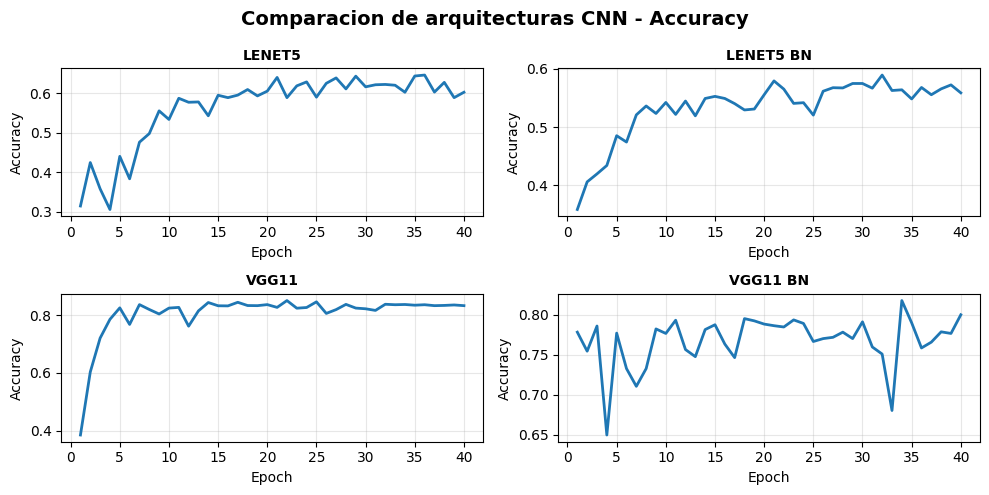

In [109]:
fig, axes = plt.subplots(2,2,figsize=(10,5))

metrics = [metrics_lenet, metrics_lenet_bn, metrics_vgg, metrics_vgg_bn]
titles = ['LENET5', 'LENET5 BN', 'VGG11', 'VGG11 BN']

for i, metric in enumerate(metrics):

    row = i // 2
    col = i % 2

    test_accuracy = [metric[i]['test_accuracy'] for i in metric]
    axes[row][col].plot(
        range(1,len(test_accuracy)+1),
        test_accuracy,
        linewidth=2
    )

    axes[row][col].set_title(titles[i], fontsize=10, fontweight='bold')
    axes[row][col].set_xlabel('Epoch')
    axes[row][col].set_ylabel('Accuracy')
    axes[row][col].grid(alpha=0.3)

plt.suptitle('Comparacion de arquitecturas CNN - Accuracy', fontsize=14, fontweight='bold')

plt.tight_layout()

In [135]:
models = [model_lenet, model_lenet_bn, model_vgg, model_vgg_bn]
table_m = {}
for i, model in enumerate(models):
    total_param = 0
    for t in model.parameters():
        total_param += t.numel()

    et = [m['epoch_time'] for m in list(metrics[i].values())]
    epoch_time = sum(et)/len(et)

    ta = [m['test_accuracy'] for m in list(metrics[i].values())]
    test_accuracy = max(ta)
    table_m[titles[i]] = {
        "Parametros": total_param,
        "Tiempo/epoca": round(epoch_time,1),
        "Mejor Accuracy": round(test_accuracy*100,1)
    }


In [138]:
import pandas as pd
df_resumen = pd.DataFrame(table_m)
df_resumen

,LENET5,LENET5 BN,VGG11,VGG11 BN
Parametros,337976.0,338020.0,8609988.0,8612740.0
Tiempo/epoca,12.1,12.5,13.0,13.0
Mejor Accuracy,64.6,58.9,85.1,81.7
